#### Modern Wage Dynamics 
ASU Math+ ABM Spring School 2024 

J M Applegate  
February 14, 2024 
With price and wage set according to hours, and useable money and inventory.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

#### import functions from model files
from series_parameters_2 import series_params
from initialisation_functions_2 import *
from firm_functions_2 import *
from household_functions_2 import *
from market_functions_2 import *
from simulation import simulation

plt.rc('font',**{'family':'sans-serif','sans-serif':['Futura']})


from numpy.random import default_rng
from operator import itemgetter

import warnings
warnings.filterwarnings('ignore')

def simulation(r, s, t_max, n, H_max, omega_0, p_0, A, gamma, mu, S_N, delta_0, theta, min_pct, rng):
    sim_results = []
    t = 0
    pct_change = delta_0

    households = np.arange(0, n)

    #### intitialise firm and household
    I, pi, total_pi, omega, p, H_D, S_P, S_S = create_firm(omega_0, p_0)
    alphas, betas, H_N, H_O, H, H_W, income, m, S, S_C, U, expenditure = create_households(n, H_max, rng)
    N, S_D, H_M, S_M, H_S = 0, 0, 0, 0, 0

    #### initialise firm effort and demand expectations
    #idxs = rng.integers(0, n, size = mu)

    #### household sample S_hat
    S_hat, demand_memory = initialise_demand_expectation(n, alphas, betas, omega, p, H_max, S_N, mu)

    #### save initial results
    step_results = [s, r, t, t_max, n, H_max, A, gamma, mu, S_N, omega_0, p_0, delta_0, theta, min_pct, pct_change,
                    I, pi, total_pi, omega, p, H_D, S_S, S_P, S_hat, N, H_S, H_M, S_D, S_M,
                    np.sum(H_N), np.sum(H_O), np.sum(m), np.median(m), np.mean(m), np.max(m), 
                    np.min(m), np.mean(U), np.mean(alphas)]
    sim_results.append(step_results)

    #### the simulation steps can be run for a fixed number, t_max, 
    #### or with the stopping condition that S_S is within 1 unit of S_D.

    #### conditional steps
    # while ((abs(S_S - S_D) >= 1 or abs(pi) >= 1) and t < t_max) or t == 0:
    #     #print('supply demand delta is', abs(S_S - S_D), 'and pi is', abs(pi))
    #     t = t + 1

    #### t_max simulation steps
    for t in range(1, t_max + 1):
        #### firm determines hours
        H_D = determine_hours(S_hat, A, gamma, S_N, n, I)

        #### households determine effort and hours supplied
        H_N = tribute_hours(p, S_N, omega, m)
        for h in range(n):
            H_O[h] = optional_hours(betas[h], alphas[h], H_max, omega, m[h], p, S_N)
        H = np.minimum(H_N + H_O, H_max)

        #### market aggregates hours supplied, determines market hours and effective effort
        H_S = np.sum(H)
        H_M = min(H_D, H_S)
        N, H_W = aggregate_effort(H_S, H_D, H)

        #### firm produces sugar with effective labour
        S_P = produce_supply(A, N, gamma)
        S_S = S_P + I

        #### households plan sugar consumption
        S, income = plan_consumption(S_N, omega, p, H_W, m)

        #### market aggregates sugar demand and determines sugar sold
        S_D = np.sum(S)
        S_M = min(S_S, S_D)
        S_C = sell_sugar(S_S, S_D, S)

        #### calculate firm profit
        pi = profit(omega, p, S_M, H_M)
        total_pi += pi

        #### calculate household utility
        U = calculate_utility(H_max, H_W, S_C, S_N, alphas, betas)

        #### households adjust ledgers
        m, expenditure = update_ledger(income, p, S_C, m)

        #### firm adjusts inventory
        I = adjust_inventory(S_P, S_M, I)

        #### firm updates demand expectations
        S_hat, demand_memory = update_expectation(S_D, demand_memory, mu)

        #### firm raises or lowers wage and price
        #pct_change = delta_0
        ### for annealing
        pct_change = decay(t, delta_0, theta, min_pct)
        omega, p = update_wage_price(omega, p, H_S, H_D, S_S, S_D, pct_change)
        min_H_D = (n * S_N / A) ** (1 / gamma)

        #### write step state to frame
        step_results = [s, r, t, t_max, n, H_max, A, gamma, mu, S_N, omega_0, p_0, delta_0, theta, min_pct, pct_change,
                        I, pi, total_pi, omega, p, H_D, S_S, S_P, S_hat, N, H_S, H_M, S_D, S_M,
                        np.sum(H_N), np.sum(H_O), np.sum(m), np.median(m), np.mean(m), np.max(m), 
                        np.min(m), np.mean(U), np.mean(alphas)]
        sim_results.append(step_results)

    return sim_results

In [2]:

#### series setup
directory, series_name, seed, reps, n_sets, series_params_list = series_params()

#### verify directory exists
from pathlib import Path
Path(directory).mkdir(parents=True, exist_ok=True)

#### initialise rng to be used by simulation series
rng = default_rng(seed)

print('This experiment consists of {} simulations'.format(n_sets * reps))
print('consisting of {} parameter sets.'.format(n_sets))

#### intitialise storage vehicle for series results
series_results = []

#### main body of multi parameter set code
for params in series_params_list:
    sim_results = simulation(*params, rng)
    series_results = series_results + sim_results

print('\nFinished series.')

macro_labels = ['set', 'run', 'step', 't_max', 'n', 'H_max', 'A', 'gamma', 'mu', 'S_N', 'omega_0', 'p_0', 'delta_0', 
                'theta', 'min_pct', 'pct_change',
                'I', 'pi', 'total_pi', 'omega', 'p', 'H_D', 'S_S', 'S_P', 'S_hat', 'N', 'H_S', 'H_M', 'S_D', 'S_M',
                'total_H_N', 'total_H_O','total_m', 'med_m', 'mean_m', 'max_m', 'min_m', 'mean_U', 'mean_alpha']

#### Transform list of lists into dataframes
series_results_frame = pd.DataFrame(series_results, columns = macro_labels)

#### For troubleshooting
#print(series_results_frame)

#### Save dataframe to directory as csv file.
# print('Writing to files.')
# prefix = directory + 'series_' + series_name
# series_results_frame.to_csv(prefix + '.csv', index = False)
# print('Series results written to', prefix + '.csv')


This experiment consists of 100 simulations
consisting of 1 parameter sets.

Finished series.


In [3]:
srf = series_results_frame
del(series_results_frame)
srf['mean_beta'] = 1 - srf['mean_alpha']
srf['ratio'] = srf['omega'] / srf['p']
srf['sugar_diff'] = abs(srf['S_S'] - srf['S_D'])
srf['hours_diff'] = abs(srf['S_S'] - srf['S_D'])
final_srf = srf[srf['step'] == max(srf['step'])]

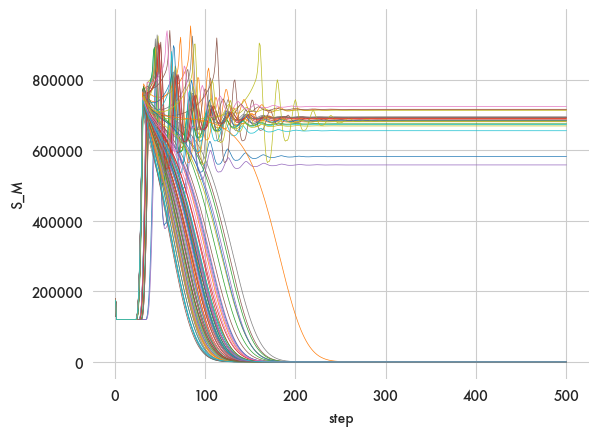

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font',**{'family':'sans-serif','sans-serif':['Futura']})

plot_data = srf[['step', 'S_M', 'run']][srf['step'] > 0][srf['theta'] == .1]
plot_data_wide = pd.pivot_table(plot_data, index = ['step'], values = ['S_M'], columns = ['run'])
plot_data_wide.plot(linewidth=.5, legend=None)

plt.ylabel('S_M')
#plt.title('Household Simulation Results')
sns.despine(left = True, bottom = True)

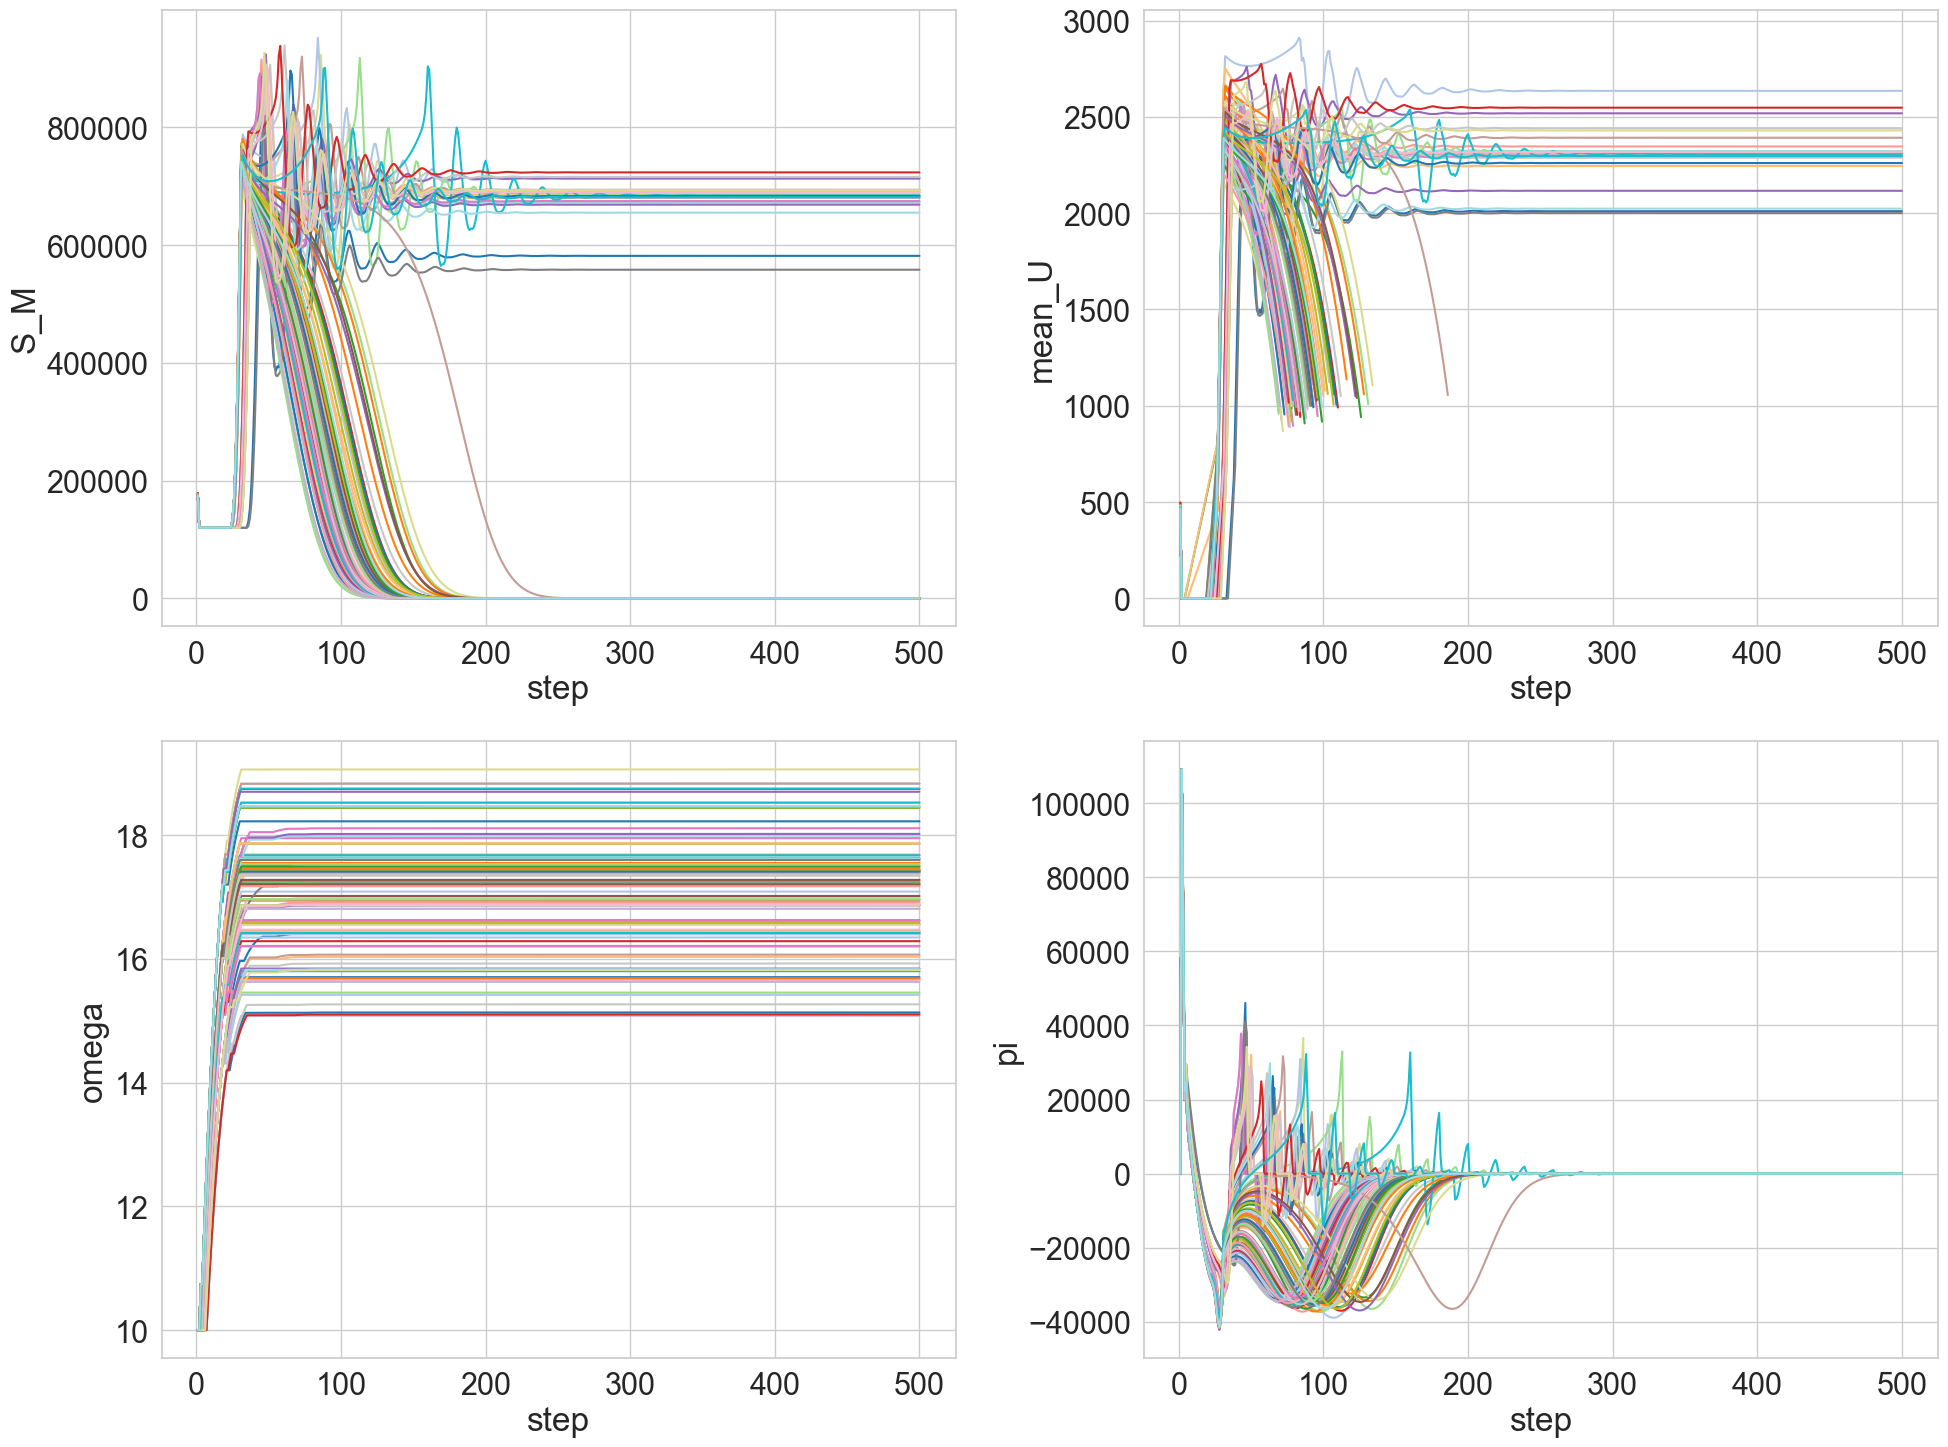

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=2)

fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(20,15), sharey=False, sharex=False,tight_layout=True)

for col, ax in zip(['S_M','mean_U','omega','pi'], axes.flat):
    sns.lineplot(data=srf.query("(step > 0) & (theta == 0.1)"), x='step', y=col, hue='run',
             ax=ax, legend=False, palette='tab20')

In [5]:
plot = plot_data_wide.plot()
plt.close()
colours = plot.lines
colour_list = []
for r in range(100):
    colour_list.append(colours[r].get_color())

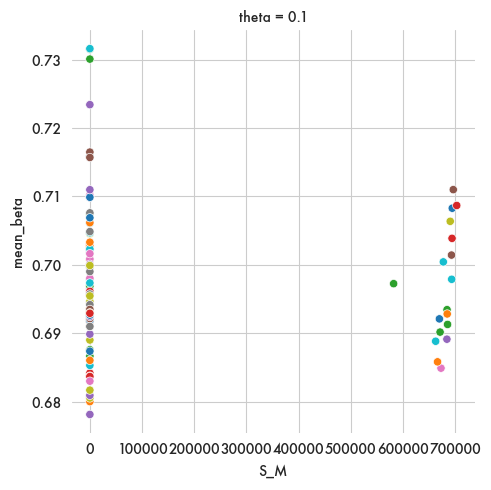

In [6]:
sns.relplot(
    data=final_srf,
    x="S_M", y="mean_beta",
    hue="run", col="theta",
    kind="scatter", 
    height=5, aspect=1, legend=None,
    palette = colour_list
)
sns.despine(left = True, bottom = True)
#plt.savefig('HoursAnnealingScanSingleHouseholdBetas.pdf')